# Train the decoder and save the results

In [1]:
import numpy as np
import pandas as pd
import pickle as pkl

import replay_trajectory_classification as rtc
import track_linearization as tl

c:\Users\ncgui\Desktop\machinelearning\docs\examples\examples\NeuralDecoding\PositionDecodingFromHippocampus\.venv\lib\site-packages\replay_trajectory_classification\likelihoods\multiunit_likelihood.py:9: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


In [2]:
positions_filename = "../../../../datasets/HippocampalTetrodeRecordings/decoder_data/position_info.pkl"
spikes_filename = "../../../../datasets/HippocampalTetrodeRecordings/decoder_data/clusterless_spike_times.pkl"
features_filename = "../../../../datasets/HippocampalTetrodeRecordings/decoder_data/clusterless_spike_features.pkl"
model_filename = "../../../../datasets/HippocampalTetrodeRecordings/decoder_data/clusterless_spike_decoder.pkl"
decoding_filename = "../../../../datasets/HippocampalTetrodeRecordings/decoder_data/clusterless_spike_decoding_results.pkl"

In [3]:
positions_df = pd.read_pickle(positions_filename)
timestamps = positions_df.index.to_numpy()
time_start = timestamps[0]
time_end = timestamps[-1]
dt = 0.02
Fs = 1.0 / dt
spikes_bins = np.arange(time_start - dt, time_end + dt, dt)

In [4]:
positions_df

,nose_x,nose_y,nose_vel,tailBase_x,tailBase_y,tailBase_vel,tailMid_x,tailMid_y,tailMid_vel,tailTip_x,...,hindpawR_vel,forelimb_mid_x,forelimb_mid_y,forelimb_vel,body_dir,linear_position,track_segment_id,projected_x_position,projected_y_position,arm_name
time,,,,,,,,,,,,,,,,,,,,,
22389.082875,6.302628,5.231174,45.320770,12.856064,5.547496,48.290909,11.367913,6.833021,56.508186,16.296467,...,NaN,5.080671,3.215346,125.707005,2.338472,162.285019,3,6.345101,8.359380,Left Arm
22389.084875,6.755276,5.644503,45.579716,13.503448,5.689286,48.483751,12.142827,7.315345,56.751256,17.387420,...,NaN,5.194684,3.302497,124.976602,2.347791,162.732014,3,6.792055,8.353311,Left Arm
22389.086875,7.207925,6.057833,45.838661,14.150832,5.831076,48.676593,12.917740,7.797669,56.994325,18.478373,...,NaN,5.308697,3.389648,124.246200,2.357110,163.179010,3,7.239009,8.347243,Left Arm
22389.088875,7.660573,6.471162,46.097607,14.798215,5.972866,48.869435,13.692654,8.279993,57.237395,19.569326,...,NaN,5.422709,3.476798,123.515797,2.366429,163.626005,3,7.685963,8.341174,Left Arm
22389.090875,8.113222,6.884492,46.356552,15.445599,6.114657,49.062277,14.467568,8.762317,57.480464,20.660279,...,NaN,5.536722,3.563949,122.785394,2.375748,164.073000,3,8.132917,8.335106,Left Arm
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23293.722875,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,-0.000057,161.447258,3,5.507417,8.370753,Left Arm
23293.724875,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,-0.000057,161.447258,3,5.507417,8.370753,Left Arm
23293.726875,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,-0.000057,161.447258,3,5.507417,8.370753,Left Arm


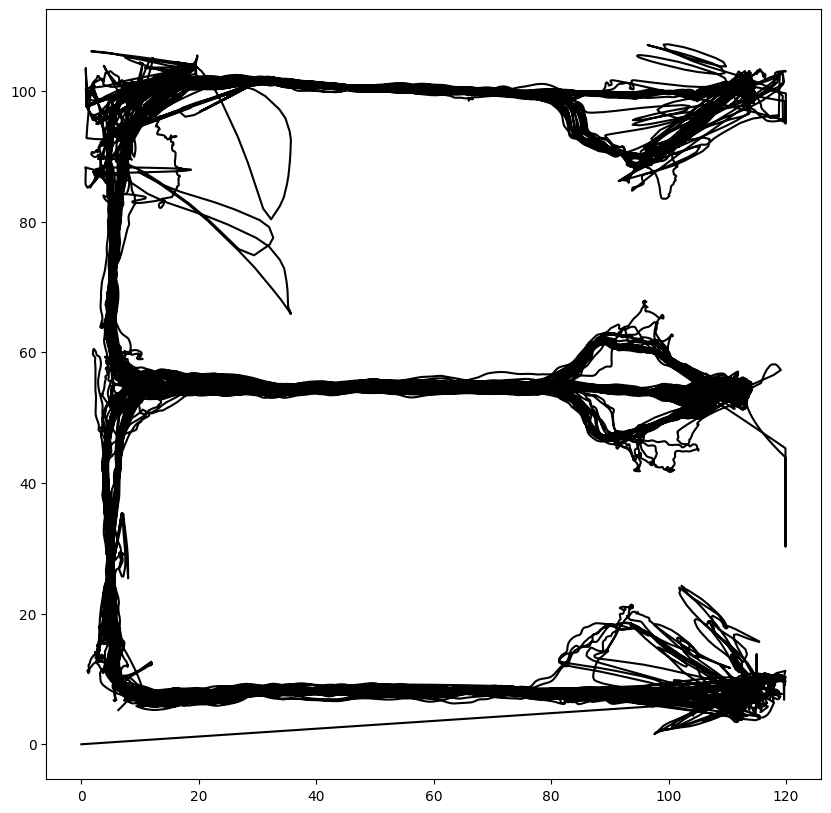

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
plt.plot(positions_df.nose_x, positions_df.nose_y, color="black")
plt.show()

In [6]:
x = positions_df["nose_x"].to_numpy()
y = positions_df["nose_y"].to_numpy()
positions = np.column_stack((x, y))
node_positions = [(120.0, 100.0),
                    (  5.0, 100.0),
                    (  5.0,  55.0),
                    (120.0,  55.0),
                    (  5.0,   8.5),
                    (120.0,   8.5),
                    ]
edges = [
            (3, 2),
            (0, 1),
            (1, 2),
            (5, 4),
            (4, 2),
        ]
track_graph = rtc.make_track_graph(node_positions, edges)

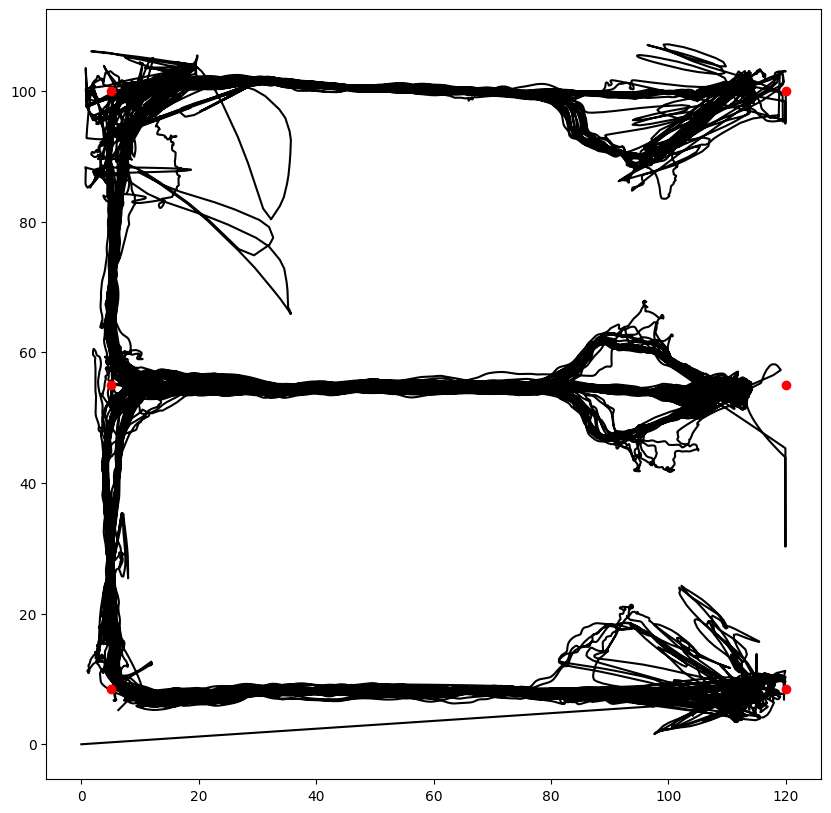

In [7]:
plt.figure(figsize=(10, 10))
plt.plot(positions_df.nose_x, positions_df.nose_y, color="black")
plt.plot([node[0] for node in node_positions], [node[1] for node in node_positions], 'o', color="red")
plt.show()

In [8]:
edge_order = [
                (3, 2),
                (0, 1),
                (1, 2),
                (5, 4),
                (4, 2),
                ]

edge_spacing = [0, 0, 0, 0]

In [9]:
with open(features_filename, "rb") as f:
    clusterless_spike_features = pkl.load(f)

with open(spikes_filename, "rb") as f:
    clusterless_spike_times = pkl.load(f)

features = np.ones((len(spikes_bins) - 1, len(clusterless_spike_features[0][0]), len(clusterless_spike_times)), dtype=float) * np.nan
for n in range(len(clusterless_spike_times)):
    in_spikes_window = np.digitize(clusterless_spike_times[n], spikes_bins) - 1
    features[in_spikes_window, :, n] = clusterless_spike_features[n]

position_at_spikes = np.ones((len(spikes_bins) - 1, 2)) * np.nan
in_position_window = np.digitize(positions_df.index, spikes_bins) - 1
position_at_spikes[in_position_window] = positions

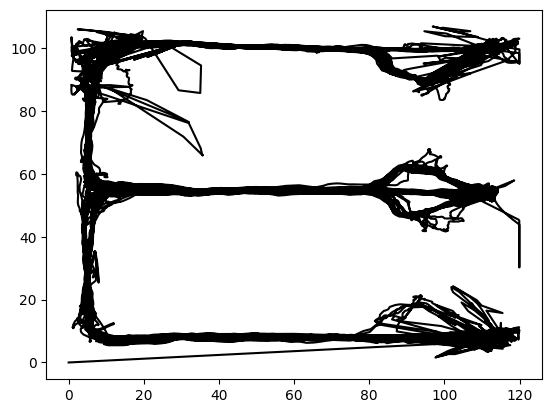

In [10]:
plt.plot(position_at_spikes[:, 0], position_at_spikes[:, 1], color="black")
plt.show()

In [ ]:
place_bin_size = 0.5
movement_var = 0.25

environment = rtc.Environment(place_bin_size=place_bin_size,
                              edge_order=edge_order,
                              edge_spacing=edge_spacing)

transition_type = rtc.RandomWalk(movement_var=movement_var)

decoder = rtc.ClusterlessDecoder(
    environment=environment,
    transition_type=transition_type,
    clusterless_algorithm="multiunit_likelihood_integer_gpu"
)

In [16]:
print("Learning model parameters")
decoder.fit(position_at_spikes, features)

Learning model parameters


c:\Users\ncgui\Desktop\machinelearning\docs\examples\examples\NeuralDecoding\PositionDecodingFromHippocampus\.venv\lib\site-packages\replay_trajectory_classification\continuous_state_transitions.py:26: RuntimeWarning: invalid value encountered in divide
  x /= x.sum(axis=1, keepdims=True)


ClusterlessDecoder(clusterless_algorithm='multiunit_likelihood_integer_gpu',
                   clusterless_algorithm_params={'mark_std': 24.0,
                                                 'position_std': 6.0},
                   environment=Environment(environment_name='',
                                           place_bin_size=0.5,
                                           track_graph=None,
                                           edge_order=None,
                                           edge_spacing=None,
                                           is_track_interior=None,
                                           position_range=None,
                                           infer_track_interior=True,
                                           fill_holes=False,
                                           dilate=False,
                                           bin_count_threshold=0),
                   infer_track_interior=True,
                   initial_conditions_type=UniformInitialConditions(),
                   transition_type=RandomWalk(environment_name='',
                                              movement_var=0.25,
                                              movement_mean=0.0,
                                              use_diffusion=False))

In [ ]:
print(f"Saving model to {model_filename}")

results = dict(decoder=decoder)

with open(model_filename, "wb") as f:
    pkl.dump(results, f)

# Decode

In [17]:
decoding_start_secs = 0
decoding_duration_secs = 100

In [18]:
print("Decoding positions from features")
decoding_start_samples = int(decoding_start_secs * Fs)
decoding_duration_samples = int(decoding_duration_secs * Fs)
time_ind = slice(decoding_start_samples, decoding_start_samples + decoding_duration_samples)
time = np.arange(len(position_at_spikes)) / Fs
decoding_results = decoder.predict(features[time_ind], time=time[time_ind])

Decoding positions from features


n_electrodes:  93%|█████████▎| 26/28 [00:24<00:01,  1.07it/s]


CUDARuntimeError: cudaErrorIllegalAddress: an illegal memory access was encountered

In [ ]:
print(f"Saving decoded results to {decoding_filename}")

results = dict(decoding_results=decoding_results,
                linear_position=linear_position[time_ind],
                spikes=features[time_ind])

with open(decoding_filename, "wb") as f:
    pkl.dump(results, f)

## Optional

Plot the decoded results

In [ ]:
import plotly.graph_objects as go

In [ ]:
fig = go.Figure()

trace = go.Heatmap(z=decoding_results.acausal_posterior.T,
                    x=decoding_results.acausal_posterior.time,
                    y=decoding_results.acausal_posterior.position,
                    zmin=0.00, zmax=0.05, showscale=False)
fig.add_trace(trace)

trace = go.Scatter(x=time[time_ind], y=linear_position,
                    mode="markers", marker={"color": "cyan", "size": 5},
                    name="position", showlegend=True)
fig.add_trace(trace)

fig.update_xaxes(title="Time (sec)")
fig.update_yaxes(title="Position (cm)")
fig.update_coloraxes(showscale=False)